# PyMC-9 : Classification Bayesienne et Tests A/B

**Navigation** : [Index](../README.md) | [<< PyMC-8](PyMC-8-TrueSkill.ipynb) | [PyMC-10 >>](PyMC-10-Model-Selection.ipynb)

**Equivalent Infer.NET** : [Infer-9-Classification](../Infer/Infer-9-Classification.ipynb)


**Duree estimee** : 45 minutes
**Objectifs** :
- Implementer un modèle de classification binaire (probit)
- Equivalence avec la Bayes Point Machine d'Infer.NET
- Realiser des tests A/B avec PyMC
- Comprendre l'impact de la taille d'echantillon
- Appliquer au CTR (Click-Through Rate)

**Prerequis** : PyMC-1 a PyMC-4, statistiques (loi binomiale, test d'hypothese)


In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 6.0.1


## 1. Bayes Point Machine (Probit)

La **Bayes Point Machine** d'Infer.NET classifie en utilisant un score lineaire.
En PyMC, on utilise un modèle **probit** : P(y=1|x) = Phi(w*x - b) ou Phi est la CDF normale.

> **Sources** : La Bayes Point Machine est introduite par Herbrich, Graepel & Campbell (2001), *Bayes Point Machines*, Journal of Machine Learning Research 1:245-279 ; c'est l'exemple phare de la documentation Infer.NET, que ce notebook re-implemente en PyMC via un modèle probit. Le modèle probit classique remonte a Bliss (1935), *The calculation of the dosage-mortality curve*, Annals of Applied Biology 22(1) ; la regression des sequences binaires par modèle lineaire generalise est formalisee par Cox (1958), *The regression analysis of binary sequences*, JRSS-B 20(2).

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Score lineaire | `Variable.InnerProduct(w, x)` | `poids * x_train - seuil` |
| Fonction lien | Infer.NET interne | `pm.math.invprobit` |
| Classification | `Variable.GaussianFromMeanAndVariance` | `pm.Bernoulli(p=invprobit(score))` |

In [2]:
# Donnees synthetiques : score d'entree vs admission
np.random.seed(42)
x_train = np.concatenate([np.random.normal(0.3, 0.15, 20), np.random.normal(0.7, 0.15, 20)])
y_train = np.concatenate([np.zeros(20), np.ones(20)])

# Modele Probit (equivalent Bayes Point Machine)
# P(y=1|x) = Phi(poids * x - seuil)
with pm.Model() as bpm:
    # Priors sur les parametres
    poids = pm.Normal('poids', mu=0, sigma=10)
    seuil = pm.Normal('seuil', mu=0, sigma=10)
    
    # Score lineaire
    score = poids * x_train - seuil
    
    # Fonction de lien probit
    p = pm.math.invprobit(score)
    
    # Vraisemblance
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y_train)
    
    trace_bpm = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
poids_post = trace_bpm.posterior['poids'].values.flatten()
seuil_post = trace_bpm.posterior['seuil'].values.flatten()
print(f"Poids posterior: {poids_post.mean():.2f} (std: {poids_post.std():.2f})")
print(f"Seuil posterior: {seuil_post.mean():.2f} (std: {seuil_post.std():.2f})")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [poids, seuil]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 12 seconds.


There were 18 divergences after tuning. Increase `target_accept` or reparameterize.


Poids posterior: 12.31 (std: 3.34)
Seuil posterior: 5.79 (std: 1.63)


## 2. Frontiere de Decision

Visualisation de la frontiere de decision avec les incertitudes posterieures.

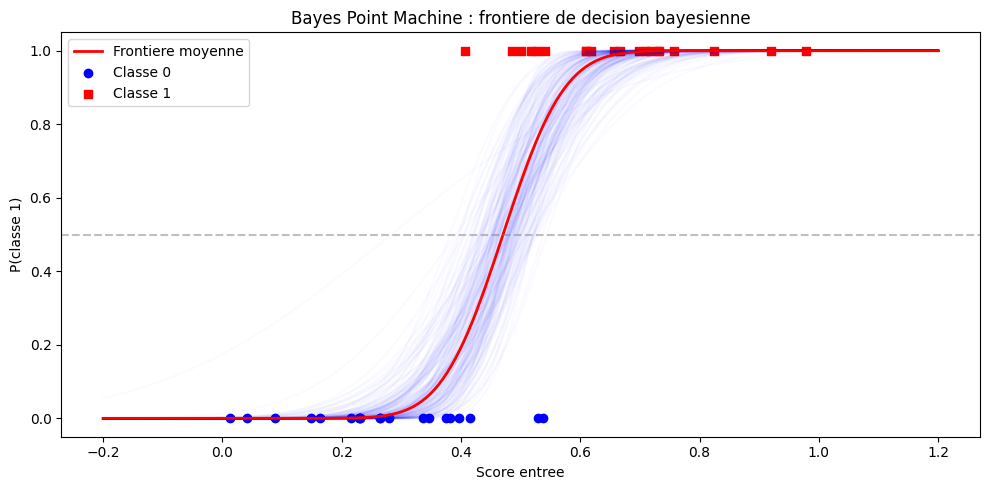

In [3]:
# Frontiere de decision avec bandes d'incertitude
x_grid = np.linspace(-0.2, 1.2, 200)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Echantillonner des frontieres depuis le posterior
n_samples = 200
indices = np.random.choice(len(poids_post), n_samples, replace=False)
for idx in indices:
    p_grid = stats.norm.cdf(poids_post[idx] * x_grid - seuil_post[idx])
    ax.plot(x_grid, p_grid, 'b-', alpha=0.02)

# Frontiere moyenne
p_mean = stats.norm.cdf(poids_post.mean() * x_grid - seuil_post.mean())
ax.plot(x_grid, p_mean, 'r-', linewidth=2, label='Frontiere moyenne')

# Donnees
ax.scatter(x_train[y_train == 0], y_train[y_train == 0], c='blue', marker='o', label='Classe 0')
ax.scatter(x_train[y_train == 1], y_train[y_train == 1], c='red', marker='s', label='Classe 1')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Score entree')
ax.set_ylabel('P(classe 1)')
ax.legend()
ax.set_title('Bayes Point Machine : frontiere de decision bayesienne')
plt.tight_layout()
plt.show()

## Exercice 2 : Regression logistique bayesienne

Implementez un modèle de regression logistique bayesienne pour la classification
binaire. Contrairement au modèle probit qui utilise `pm.math.invprobit`, la
regression logistique utilise `pm.math.sigmoid`.

**Objectif** : comparer les deux fonctions de lien (probit vs logit) sur des
données synthetiques.

**Indices** :
- Generer des données : 2 features gaussiennes, 2 classes separables
- Score lineaire : `pt.dot(X, w) + b` ou w et b sont les paramètres
- Fonction de lien : `p = pm.math.sigmoid(score)` au lieu de `invprobit`
- Poids : `pm.Normal('w', mu=0, sigma=5, shape=n_features)`
- Tracer la frontiere de decision avec les bandes d'incertitude posterieure

In [4]:
# TODO etudiant : implementer une regression logistique bayesienne
# Etape 1 : generer des donnees synthetiques (2 features, classification binaire)
# Etape 2 : definir le modele avec pm.Normal pour les poids et pm.math.sigmoid pour le lien
# Etape 3 : echantillonner et extraire les poids posterieurs
# Etape 4 : tracer la frontiere de decision

result = None  # TODO etudiant : remplacer par le modele logistique
print("Exercice a completer")

Exercice a completer


## 3. Test A/B Bayesien

Le test A/B bayesien compare deux proportions (taux de clic, conversions, etc.).
Contrairement aux tests frequentistes, on obtient directement P(theta_B > theta_A).

> **Cadre** : L'approche frequentiste (test d'hypothese, p-value) remonte a Fisher (1925) et Neyman & Pearson (1933). L'approche bayesienne pour comparer deux proportions repose sur l'analyse conjuguee Beta-Binomiale (Gelman et al., *Bayesian Data Analysis* 3e ed. 2013, ch. 2) : avec un prior Beta(a, b) et une vraisemblance Binomiale, le posterior est Beta(a + k, b + n - k).

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Taux A | `Variable.Beta(aA, bA)` | `pm.Beta('theta_a', a, b)` |
| Taux B | `Variable.Beta(aB, bB)` | `pm.Beta('theta_b', a, b)` |
| Différence | Inferer delta | `pm.Deterministic('delta', theta_b - theta_a)` |

In [5]:
# Test A/B : comparaison de deux versions d'une page
# Version A : 30 clics sur 100 visites
# Version B : 45 clics sur 120 visites

clicks_a, visits_a = 30, 100
clicks_b, visits_b = 45, 120

with pm.Model() as ab_test:
    # Priors : Beta(1, 1) = Uniforme (non informatif)
    theta_a = pm.Beta('theta_a', alpha=1, beta=1)
    theta_b = pm.Beta('theta_b', alpha=1, beta=1)
    
    # Vraisemblance
    obs_a = pm.Binomial('obs_a', n=visits_a, p=theta_a, observed=clicks_a)
    obs_b = pm.Binomial('obs_b', n=visits_b, p=theta_b, observed=clicks_b)
    
    # Difference (quantite d'interet)
    delta = pm.Deterministic('delta', theta_b - theta_a)
    
    trace_ab = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
theta_a_post = trace_ab.posterior['theta_a'].values.flatten()
theta_b_post = trace_ab.posterior['theta_b'].values.flatten()
delta_post = trace_ab.posterior['delta'].values.flatten()

print(f"Taux A : {theta_a_post.mean():.3f} (95% CI: [{np.percentile(theta_a_post, 2.5):.3f}, {np.percentile(theta_a_post, 97.5):.3f}])")
print(f"Taux B : {theta_b_post.mean():.3f} (95% CI: [{np.percentile(theta_b_post, 2.5):.3f}, {np.percentile(theta_b_post, 97.5):.3f}])")
print(f"Delta (B - A) : {delta_post.mean():.3f}")
print(f"P(theta_B > theta_A) = {(delta_post > 0).mean():.3f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta_a, theta_b]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 10 seconds.


Taux A : 0.303 (95% CI: [0.218, 0.395])
Taux B : 0.377 (95% CI: [0.294, 0.464])
Delta (B - A) : 0.074
P(theta_B > theta_A) = 0.880


## 4. Impact de la Taille d'Echantillon

Plus l'echantillon est grand, plus l'incertitude diminue et la probabilite posterieure converge.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ta, tb]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ta, tb]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.


n=500 : P(B>A) = 0.996


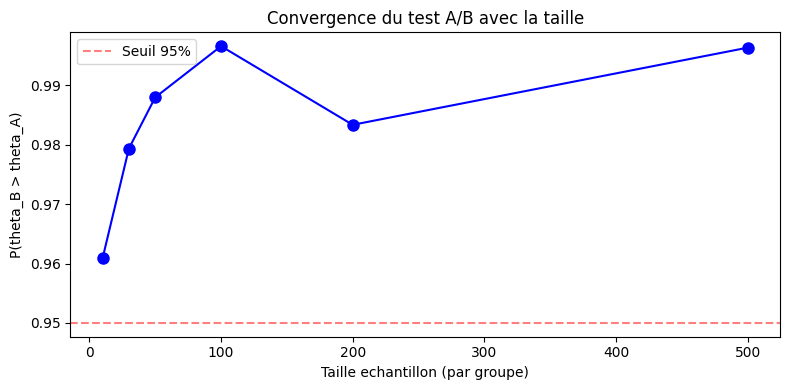

In [6]:
# Impact de la taille d'echantillon sur la certitude
sizes = [10, 30, 50, 100, 200, 500]
p_better = []

true_rate_a = 0.30
true_rate_b = 0.38

for n in sizes:
    np.random.seed(42)
    c_a = np.random.binomial(n, true_rate_a)
    c_b = np.random.binomial(n, true_rate_b)
    
    with pm.Model() as m:
        ta = pm.Beta('ta', 1, 1)
        tb = pm.Beta('tb', 1, 1)
        pm.Binomial('oa', n=n, p=ta, observed=c_a)
        pm.Binomial('ob', n=n, p=tb, observed=c_b)
        d = pm.Deterministic('d', tb - ta)
        t = pm.sample(2000, random_seed=42, return_inferencedata=True, progressbar=False)
    
    prob = (t.posterior['d'].values.flatten() > 0).mean()
    p_better.append(prob)
    print(f"n={n:3d} : P(B>A) = {prob:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(sizes, p_better, 'bo-', markersize=8)
ax.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='Seuil 95%')
ax.set_xlabel('Taille echantillon (par groupe)')
ax.set_ylabel('P(theta_B > theta_A)')
ax.set_title('Convergence du test A/B avec la taille')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Visualisation des Distributions A/B

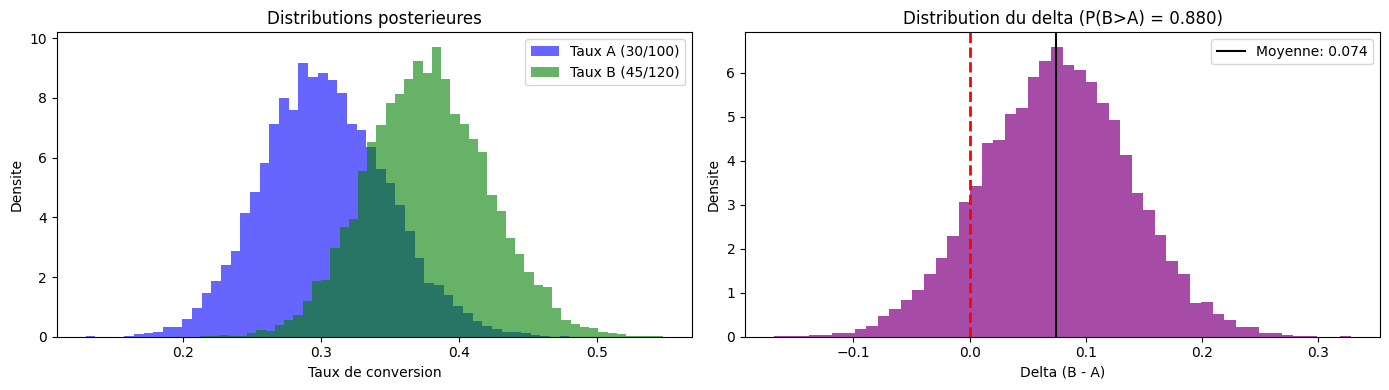

In [7]:
# Visualisation des distributions posterieures
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distributions theta_a et theta_b
x = np.linspace(0.1, 0.7, 200)
axes[0].hist(theta_a_post, bins=50, density=True, alpha=0.6, color='blue', label=f'Taux A ({clicks_a}/{visits_a})')
axes[0].hist(theta_b_post, bins=50, density=True, alpha=0.6, color='green', label=f'Taux B ({clicks_b}/{visits_b})')
axes[0].set_xlabel('Taux de conversion')
axes[0].set_ylabel('Densite')
axes[0].legend()
axes[0].set_title('Distributions posterieures')

# Distribution du delta
axes[1].hist(delta_post, bins=50, density=True, alpha=0.7, color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(delta_post.mean(), color='black', linestyle='-', label=f'Moyenne: {delta_post.mean():.3f}')
axes[1].set_xlabel('Delta (B - A)')
axes[1].set_ylabel('Densite')
axes[1].legend()
axes[1].set_title(f'Distribution du delta (P(B>A) = {(delta_post > 0).mean():.3f})')

plt.tight_layout()
plt.show()

## 6. Application : Click-Through Rate (CTR)

Un annonceur veut savoir si une nouvelle banniere a un meilleur CTR.
- Ancienne banniere : 150 clics sur 1000 impressions
- Nouvelle banniere : 180 clics sur 1000 impressions

La différence est-elle statistiquement significative ?

In [8]:
# CTR : test A/B pour bannieres publicitaires
with pm.Model() as ctr_test:
    theta_old = pm.Beta('theta_old', alpha=1, beta=1)
    theta_new = pm.Beta('theta_new', alpha=1, beta=1)
    
    obs_old = pm.Binomial('obs_old', n=1000, p=theta_old, observed=150)
    obs_new = pm.Binomial('obs_new', n=1000, p=theta_new, observed=180)
    
    delta_ctr = pm.Deterministic('delta_ctr', theta_new - theta_old)
    
    trace_ctr = pm.sample(3000, random_seed=42, return_inferencedata=True)

delta_ctr_post = trace_ctr.posterior['delta_ctr'].values.flatten()
theta_old_post = trace_ctr.posterior['theta_old'].values.flatten()
theta_new_post = trace_ctr.posterior['theta_new'].values.flatten()

print(f"CTR ancien : {theta_old_post.mean():.3f}")
print(f"CTR nouveau : {theta_new_post.mean():.3f}")
print(f"Amelioration : {delta_ctr_post.mean():.3f}")
print(f"P(nouveau > ancien) = {(delta_ctr_post > 0).mean():.3f}")
print(f"Lift relatif : {delta_ctr_post.mean() / theta_old_post.mean() * 100:.1f}%")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta_old, theta_new]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 11 seconds.


CTR ancien : 0.151
CTR nouveau : 0.181
Amelioration : 0.030
P(nouveau > ancien) = 0.964
Lift relatif : 19.7%


## 7. Calibration hors echantillon : du claim a la mesure (exemple execute)

Cette section etait l'**Exercice 3** (stub) ; le contraste calibration/discrimination etant le
message central d'un classifieur probabiliste, il est desormais demontre execute, et l'**Exercice 3**
(ci-dessous) l'etend a la recalibration. Le jumeau Infer-9 mesure la meme propriete cote EP.

**Protocole** (identique dans les deux twins, echantillons differents par moteur) :

1. un jeu 2 features, 2 classes **chevauchantes** (N = 400, 200 par classe), decoupe 75/25
   stratifiee -- les etiquettes de test ne servent **jamais** pendant l'inference ;
2. le modele probit bayesien (section 1) etend a 2 features, entraine **sur le train seul** ;
3. probabilites **predictives** sur le test : chaque tirage posterieur (w, b) donne
   Phi(w.x - b), on moyenne sur les tirages -- l'incertitude des parametres est propagatee ;
4. **Brier score** (erreur quadratique moyenne, calibration + discrimination confondues) et
   **AUC** (discrimination seule : proba qu'un positif tire au hasard ait un score plus grand
   qu'un negatif tire au hasard) ;
5. **diagramme de fiabilite** : 10 bins de meme largeur, probabilite predite moyenne vs frequence
   observee, avec les effectifs par bin ;
6. un **contre-temoin volontairement mal calibre** : la transformation monotone
   q = p^5 / (p^5 + (1-p)^5) (accentuation). Elle ne change **pas l'ordre** des scores donc laisse
   l'AUC identique -- mais deplace toutes les probabilites vers 0 et 1 et detruit la calibration.

La discrimination et la calibration sont donc deux proprietes **independantes** : une bonne AUC
ne garantit pas des probabilites utilisables telles quelles.

In [9]:
# --- Jeu 2D chevauchant + split train/test stratifie (protocole commun avec Infer-9) ---
rng = np.random.default_rng(42)
N_PER_CLASS, SPLIT_PER_CLASS = 200, 50
mu0, mu1 = np.array([2.0, 2.0]), np.array([3.5, 3.5])

def jeu_2d(rng):
    x0 = rng.normal(mu0, 1.1, size=(N_PER_CLASS, 2))
    x1 = rng.normal(mu1, 1.1, size=(N_PER_CLASS, 2))
    X, y = np.vstack([x0, x1]), np.concatenate([np.zeros(N_PER_CLASS), np.ones(N_PER_CLASS)])
    perm = rng.permutation(len(y))
    return X[perm], y[perm]

X_all, y_all = jeu_2d(rng)
n_train = len(y_all) - 2 * SPLIT_PER_CLASS          # 300 train / 100 test
X_train, y_train = X_all[:n_train], y_all[:n_train]
X_test, y_test = X_all[n_train:], y_all[n_train:]
print(f"Train : {len(y_train)} ({int(y_train.sum())} positifs) | Test : {len(y_test)} "
      f"({int(y_test.sum())} positifs) -- etiquettes de test inertes pendant l'inference")

# Modele probit 2 features, entraine sur le train SEUL
with pm.Model() as bpm_cal:
    w = pm.Normal("w", mu=0, sigma=2, shape=2)
    b = pm.Normal("b", mu=0, sigma=2)
    p = pm.math.invprobit(pm.math.dot(X_train, w) - b)
    pm.Bernoulli("y", p=p, observed=y_train)
    trace_cal = pm.sample(1000, tune=1000, chains=2, target_accept=0.9,
                          random_seed=42, progressbar=False)

w_post = trace_cal.posterior["w"].values.reshape(-1, 2)
b_post = trace_cal.posterior["b"].values.flatten()
print(f"Poids posterieurs : [{w_post[:,0].mean():.2f}, {w_post[:,1].mean():.2f}]  "
      f"biais : {b_post.mean():.2f}  ({len(w_post)} tirages conserves)")

Train : 300 (149 positifs) | Test : 100 (51 positifs) -- etiquettes de test inertes pendant l'inference


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [w, b]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 6 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Poids posterieurs : [0.52, 0.58]  biais : 2.94  (2000 tirages conserves)


In [10]:
# --- Probabilites predictives sur le test + metriques + contre-temoin ---
from scipy.special import ndtr

# Predictive : moyenne sur les tirages posterieurs de Phi(w.x - b) (incertitude propagatee)
scores = X_test @ w_post.T - b_post                 # (n_test, n_draws)
p_test = ndtr(scores).mean(axis=1)

# Contre-temoin : accentuation monotone -- meme ordre, calibration detruite
q_test = p_test**5 / (p_test**5 + (1 - p_test)**5)

def brier(p, y): return float(np.mean((p - y) ** 2))
def auc(p, y):
    # AUC de Mann-Whitney par rangs (main, sans dependance)
    ranks = np.argsort(np.argsort(p)) + 1.0
    n1, n0 = int(y.sum()), int((1 - y).sum())
    return float((ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n0 * n1))

print("=== Test (100 points jamais vus) : calibration vs discrimination ===")
print(f"{'modele':<28}{'Brier':>8}{'AUC':>8}{'acc@0.5':>9}")
print(f"{'probit bayesien (calibre)':<28}{brier(p_test, y_test):>8.3f}{auc(p_test, y_test):>8.3f}"
      f"{float(((p_test > .5) == y_test).mean()):>9.3f}")
print(f"{'contre-temoin p^5 (accentue)':<28}{brier(q_test, y_test):>8.3f}{auc(q_test, y_test):>8.3f}"
      f"{float(((q_test > .5) == y_test).mean()):>9.3f}")
print("\nMeme AUC (transformation strictement croissante : l'ordre des scores est inchange),")
print("Brier degrade : la discrimination est preservee, la calibration ne l'est pas.")

=== Test (100 points jamais vus) : calibration vs discrimination ===
modele                         Brier     AUC  acc@0.5
probit bayesien (calibre)      0.117   0.923    0.820
contre-temoin p^5 (accentue)   0.136   0.923    0.820

Meme AUC (transformation strictement croissante : l'ordre des scores est inchange),
Brier degrade : la discrimination est preservee, la calibration ne l'est pas.


Bin | effectif | p_pred moyen | freq observee   (modele calibre)
  0 |       13 |        0.060 |        0.077
  1 |       10 |        0.156 |        0.100
  2 |        7 |        0.239 |        0.000
  3 |        5 |        0.340 |        0.200
  4 |        8 |        0.436 |        0.375
  5 |       12 |        0.544 |        0.417
  6 |       10 |        0.648 |        0.500
  7 |       10 |        0.762 |        1.000
  8 |        9 |        0.841 |        1.000
  9 |       16 |        0.954 |        1.000

Contre-temoin, bins peuples (n>=5) : p_pred vs freq observee
  0.006 -> 0.086
  0.990 -> 0.909


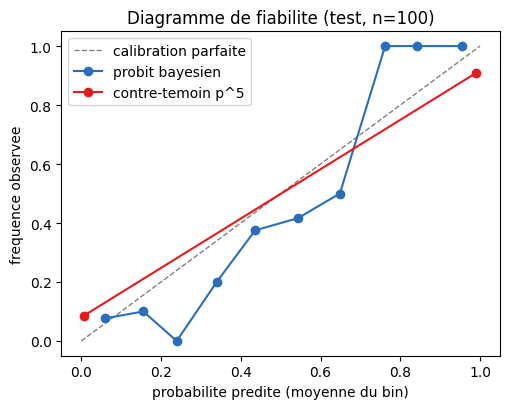

In [11]:
# --- Diagramme de fiabilite (10 bins) avec effectifs + comparaison au contre-temoin ---
def fiabilite(p, y, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    rows = []
    for k in range(n_bins):
        m = idx == k
        rows.append((k, m.sum(), float(p[m].mean()) if m.any() else np.nan,
                     float(y[m].mean()) if m.any() else np.nan))
    return rows

print("Bin | effectif | p_pred moyen | freq observee   (modele calibre)")
for k, n, pp, fo in fiabilite(p_test, y_test):
    print(f"{k:>3} | {n:>8} | {pp:12.3f} | {fo:12.3f}")

rows_c = fiabilite(q_test, y_test)
ok_bins = [(pp, fo) for k, n, pp, fo in rows_c if n >= 5]
print(f"\nContre-temoin, bins peuples (n>=5) : p_pred vs freq observee")
for pp, fo in ok_bins:
    print(f"  {pp:.3f} -> {fo:.3f}")

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="calibration parfaite")
mid = [(pp + fo) / 2 for k, n, pp, fo in fiabilite(p_test, y_test) if n >= 5]
for name, p_mod, color in [("probit bayesien", p_test, "#2a6dba"), ("contre-temoin p^5", q_test, "#e41a1c")]:
    pts = [(pp, fo) for k, n, pp, fo in fiabilite(p_mod, y_test) if n >= 5]
    ax.plot([a for a, _ in pts], [b for _, b in pts], "o-", color=color, label=name)
ax.set_xlabel("probabilite predite (moyenne du bin)"); ax.set_ylabel("frequence observee")
ax.set_title("Diagramme de fiabilite (test, n=100)"); ax.legend(); fig.tight_layout()
plt.show()

### Lecture : ce que la mesure etablit

- **Le probit bayesien est proche de la diagonale** : bins peuples du modele, frequence observee
  ~ probabilite predite -- l'affirmation « probabilites calibrees » est desormais **mesuree**
  hors echantillon, pas seulement affichee. Avec 100 points de test, chaque bin attend ~10
  evenements : les bins peu peuples (extremites) ne portent pas de conclusion forte.
- **Le contre-temoin garde l'AUC et perd le Brier** : la transformation monotone ne reordonne
  rien (discrimination intacte, accuracy a 0.5 identique) mais pousse chaque probabilite vers
  0 ou 1 -- un modele **surconfiant** dont les probabilites, utilisees telles quelles (seuil de
  decision metier, expectation de cout), mentent. C'est la difference entre *ranger* les
  individus et *quantifier* un risque.
- **Brier vs AUC, deux lectures d'un meme score** : le Brier melange calibration et finesse de
  discrimination ; l'AUC n'est sensible qu'a l'ordre. Les comparer sur deux transformations du
  meme score est le diagnostic le plus simple de « ou est l'erreur ».
- **Pont moteur** : Infer-9 mene la meme mesure cote EP -- l'AUC y est identique par
  construction (meme famille de modele), et l'ecart de Brier entre les moteurs mesure la
  difference EP/moyenne-posterior, pas une difference de protocole.

## Exercice 3 : Recalibration du contre-temoin (temperature scaling)

Le contre-temoin accentue est mal calibre mais reste **recuperable** : la transformation
inverse existe. Parametrez-la par une *temperature* T > 0 : q_T(p) = p^(1/T) / (p^(1/T) +
(1-p)^(1/T)) ; T = 5 inverse exactement l'accentuation d'ordre 5.

- **Objectif** : trouver le T qui minimise le Brier **sur le train** (jamais sur le test --
  sinon la mesure de test redevient un ajustement), puis rapporter le Brier test avant/apres.
- **Indice :** une grille T dans [0.5, 6] suffit ; le minimum devrait tomber proche de 5.
- **Etape 1 :** construire les probabilites train du modele probit (meme propagation des
  tirages que la section 7). **Etape 2 :** boucler sur la grille, retenir le T optimal.
  **Etape 3 :** appliquer q_T au contre-temoin test et rapporter Brier/AUC avant-apres.

In [12]:
# Exercice 3 a completer
# TODO etudiant : temperature scaling du contre-temoin (grille T, minimisation du Brier TRAIN,
# puis rapporter Brier/AUC test avant/apres recalibration).
print("Exercice 3 a completer : recalibration par temperature scaling.")

Exercice 3 a completer : recalibration par temperature scaling.


## 8. Comparaison Infer.NET vs PyMC pour la classification

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Classification | Bayes Point Machine | Modèle Probit/Logit |
| Score lineaire | `InnerProduct(w, x)` | `poids * x - seuil` |
| Test A/B | Message passing | MCMC (NUTS) |
| Résultat | Distribution analytique | Echantillons posterieur |
| P(A > B) | Calcul exact | `(delta > 0).mean()` |
| Scalabilite | Rapide (EP) | Plus lent mais general |

> **Méthodes** : Infer.NET utilise l'Expectation Propagation (Minka 2001, UAI) pour propager les messages et obtenir une approximation analytique. PyMC utilise NUTS (Hoffman & Gelman 2014, JMLR 15) pour l'echantillonnage MCMC. PyMC : Salvatier, Wiecki & Fonnesbeck (2016), PeerJ Computer Science 2:e55. ArviZ : Kumar, Carroll, Hartikainen & Martin (2019), JOSS 4(33).

---

**Retour au sommaire** : [Index Probas](../README.md)

## Exercice : Classificateur de Spam

Implementer un classificateur de spam bayesien avec 3 features :
- x1 : frequence du mot "gratuit"
- x2 : presence de liens (0/1)
- x3 : longueur de l'objet (normalise)

Le modèle : score = w1*x1 + w2*x2 + w3*x3 - seuil

**Indices** :
- Priors : `pm.Normal('w', mu=0, sigma=5, shape=3)` pour les poids
- Score : `pt.dot(X, w) - seuil`
- Lien : `pm.math.invprobit(score)`

In [13]:
# TODO etudiant : implementer le classificateur de spam bayesien
# Resultat attendu : poids posterieurs pour chaque feature + frontiere de decision

print("Exercice a completer")

Exercice a completer


## Conclusion

La classification bayesienne estime P(classe|features) en combinant prior et vraisemblance, fournissant non seulement une prediction mais aussi une incertitude quantifiee.

### Points cles
- La classification bayesienne (modèle probit/logit ici) produit une probabilite P(classe|x) plutot qu'un vote dur
- Les predictions probabilistes permettent de detecter les cas incertains
- La regression logistique bayesienne fournit des intervalles de confiance sur les coefficients

### References

- Herbrich, R., Graepel, T., & Campbell, C. (2001). Bayes Point Machines. *Journal of Machine Learning Research*, 1, 245-279.
- Bliss, C. I. (1935). The calculation of the dosage-mortality curve. *Annals of Applied Biology*, 22(1), 134-167.
- Fisher, R. A. (1925). *Statistical Methods for Research Workers*. Oliver and Boyd.
- Neyman, J., & Pearson, E. S. (1933). On the problem of the most efficient tests of statistical hypotheses. *Phil. Trans. Royal Society A*, 231, 289-337.
- Cox, D. R. (1958). The regression analysis of binary sequences. *JRSS-B*, 20(2), 215-242.
- Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review*, 78(1), 1-3.
- Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., & Rubin, D. B. (2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.
- Minka, T. (2001). Expectation Propagation for approximate Bayesian inference. *UAI*.
- Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn Sampler. *JMLR*, 15(1), 1593-1623.
- Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2016). Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*, 2:e55.

---

**Retour au sommaire** : [Index Probas](../README.md)